# A题问题1：逐行实际形状—严格截断 GJK—并查集判定与 BFS 路径

本 Notebook 采用已经确定的计算口径：

1. Excel 中每一行直接作为一个独立导体节点；
2. 不识别或拼接同源行，不恢复 5000 nm 父圆柱，不补全缺失轴段；
3. 不生成或平移任何附件未列出的周期副本；
4. 内部端点作为真实圆形端盖，边界端点作为边界平面切点；
5. AABB 和未截断辅助圆柱只用于安全粗筛，最终距离由严格截断支持函数 + GJK 给出；
6. 左右两个 X 面是不同电极：并查集判断是否导通；导通后再用 BFS 提取一条展示路径。

边界端点处的辅助圆柱只延伸到盒外，盒外部分立即被裁掉；它不构成新节点，
不表示补全，也不平移到相对边界。

In [1]:
from __future__ import annotations

from collections import deque
from pathlib import Path
from time import perf_counter
from typing import Dict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.lines import Line2D

import q1_gjk_strict as strict_data
import q1_gjk_independent_fragments as direct_model
from q1_gjk import CONDUCTION_DISTANCE_NM, Cylinder, gjk_distance

np.set_printoptions(precision=10, suppress=True)
pd.set_option("display.max_colwidth", 180)
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
try:
    get_ipython().run_line_magic("matplotlib", "inline")
    IN_NOTEBOOK = True
except NameError:
    IN_NOTEBOOK = False

CONDUCTION_THRESHOLD = float(CONDUCTION_DISTANCE_NM)
PROJECT_ROOT = Path.cwd()
INPUT_PATH = strict_data.INPUT

required_files = [
    PROJECT_ROOT / "q1_gjk.py",
    PROJECT_ROOT / "q1_gjk_strict.py",
    PROJECT_ROOT / "q1_gjk_independent_fragments.py",
    PROJECT_ROOT / "exact_clipped_cylinder.py",
    INPUT_PATH,
]
missing = [str(path) for path in required_files if not path.exists()]
if missing:
    raise FileNotFoundError("缺少运行所需文件：\n" + "\n".join(missing))

print("项目目录：", PROJECT_ROOT.resolve())
print("读取附件：", INPUT_PATH.resolve())
print("计算口径：一行一个独立实际片段；不拼接、不补全、不生成周期副本")
print("导通阈值：", CONDUCTION_THRESHOLD, "nm")

项目目录： E:\HuaShuBei
读取附件： E:\HuaShuBei\A题 微构体中填充导电介质的仿真优化\附件.xlsx
计算口径：一行一个独立实际片段；不拼接、不补全、不生成周期副本
导通阈值： 1.8 nm


## 1. 读取附件并审计轴段

附件中每一行的两个点只用于确定该独立片段的轴线方向和可见轴段。数据行编号从1开始，
与后续节点编号完全一致。

In [2]:
loaded = strict_data.load_segments()

input_rows = []
for sheet_name, (half_extents, segments) in loaded.items():
    lengths = np.asarray([segment.length for segment in segments])
    input_rows.append({
        "分组": sheet_name,
        "附件行数": len(segments),
        "独立节点数": len(segments),
        "最短轴段/nm": float(lengths.min()),
        "最长轴段/nm": float(lengths.max()),
        "轴长小于5000的行数": int(np.sum(lengths < 5000.0 - 1e-6)),
        "采用的半边界XYZ/nm": tuple(map(float, half_extents)),
    })

input_summary = pd.DataFrame(input_rows)
display(input_summary)
assert input_summary["附件行数"].equals(input_summary["独立节点数"])

,分组,附件行数,独立节点数,最短轴段/nm,最长轴段/nm,轴长小于5000的行数,采用的半边界XYZ/nm
0,组1,12,12,1019.117255,5000.0,10,"(5000.0, 500.0, 500.0)"
1,组2,49,49,577.473950,5000.0,38,"(5000.0, 500.0, 500.0)"
2,组3,535,535,525.697382,5000.0,380,"(5000.0, 5000.0, 5000.0)"


## 2. 逐行实际形状

对附件行轴线端点 \(A,B\)，内部端点作为真实圆形端盖；位于任一盒面的端点作为边界切点。
边界端点一侧只建立足够长的辅助圆柱，再与主单元盒求交，从而获得与边界面共面的真实切面。

\[
P_i=\{\text{第 }i\text{ 行的半径30 nm圆柱}\}\cap B.
\]

辅助圆柱的盒外部分不进入最终几何，不生成额外节点，也不平移到相对边界。

In [3]:
models: Dict[str, dict] = {}
endpoint_rows = []

for sheet_name, (half_extents, segments) in loaded.items():
    nodes = direct_model.build_row_pieces(segments, half_extents)
    models[sheet_name] = {
        "half_extents": half_extents,
        "segments": segments,
        "nodes": nodes,
    }
    endpoint_rows.append({
        "分组": sheet_name,
        "附件行数": len(segments),
        "最终独立片段数": len(nodes),
        "补生成片段数": 0,
        "起点为边界切点": sum(bool(node.start_boundary_faces) for node in nodes),
        "终点为边界切点": sum(bool(node.end_boundary_faces) for node in nodes),
        "两端均为内部端盖": sum(
            not node.start_boundary_faces and not node.end_boundary_faces
            for node in nodes
        ),
    })

construction_summary = pd.DataFrame(endpoint_rows)
display(construction_summary)
assert construction_summary["附件行数"].equals(construction_summary["最终独立片段数"])
assert construction_summary["补生成片段数"].eq(0).all()

,分组,附件行数,最终独立片段数,补生成片段数,起点为边界切点,终点为边界切点,两端均为内部端盖
0,组1,12,12,0,7,6,2
1,组2,49,49,0,22,24,11
2,组3,535,535,0,206,204,155


## 3. 不补全与节点一一对应审计

本节验证三件事：每行恰好生成一个节点；节点编号等于附件数据行号；严格截断几何完全位于主单元内。
这里不存在父圆柱编号、同源合并、连续补全参数或周期单元索引。

In [4]:
geometry_audit_rows = []

for sheet_name, model in models.items():
    half_extents = model["half_extents"]
    nodes = model["nodes"]
    segments = model["segments"]
    all_inside = True
    endpoints_feasible = True

    for node, segment in zip(nodes, segments):
        lower, upper = node.geometry.aabb()
        all_inside &= bool(
            np.all(lower >= -half_extents - 2e-6)
            and np.all(upper <= half_extents + 2e-6)
        )
        for point in (segment.p0, segment.p1):
            local = np.linalg.solve(
                node.geometry._map,
                point - node.geometry.cylinder_center,
            )
            endpoints_feasible &= node.geometry._feasible(local, tol=2e-7)

    geometry_audit_rows.append({
        "分组": sheet_name,
        "节点编号唯一": len({node.piece_id for node in nodes}) == len(nodes),
        "节点编号=附件行号": all(
            node.piece_id == segment.row_id == node.source_rows[0]
            for node, segment in zip(nodes, segments)
        ),
        "全部片段位于主单元": all_inside,
        "附件轴线端点属于片段": endpoints_feasible,
        "补生成片段数": 0,
    })

geometry_audit = pd.DataFrame(geometry_audit_rows)
display(geometry_audit)
assert geometry_audit[["节点编号唯一", "节点编号=附件行号", "全部片段位于主单元", "附件轴线端点属于片段"]].all(axis=None)
assert geometry_audit["补生成片段数"].eq(0).all()

,分组,节点编号唯一,节点编号=附件行号,全部片段位于主单元,附件轴线端点属于片段,补生成片段数
0,组1,True,True,True,True,0
1,组2,True,True,True,True,0
2,组3,True,True,True,True,0


## 4. 真实截断片段的支持函数

片段采用 ExactClippedCylinder 表示，不把圆周离散成多边形。局部变量满足

\[
|z_0|\le 1,\qquad z_1^2+z_2^2\le1,\qquad Az\le b,
\]

每次支持查询直接求解约束下的线性目标。常规活动集使用线性方程、零空间椭圆极值和 KKT
条件；退化活动集使用三变量 SLSQP 回退。

In [5]:
support_audit_rows = []
coordinate_directions = np.vstack((np.eye(3), -np.eye(3)))

for sheet_name, model in models.items():
    maximum_violation = 0.0
    for node in model["nodes"]:
        geometry = node.geometry
        for direction in coordinate_directions:
            point = geometry.support(direction)
            local = np.linalg.solve(
                geometry._map,
                point - geometry.cylinder_center,
            )
            a, b = geometry._linear_constraints
            linear_violation = max(0.0, float(np.max(a @ local - b)))
            radial_violation = max(
                0.0,
                float(local[1] ** 2 + local[2] ** 2 - 1.0),
            )
            maximum_violation = max(maximum_violation, linear_violation, radial_violation)

    support_audit_rows.append({
        "分组": sheet_name,
        "检查片段数": len(model["nodes"]),
        "每片段坐标支持方向数": len(coordinate_directions),
        "最大无量纲约束残差": maximum_violation,
    })

support_audit = pd.DataFrame(support_audit_rows)
display(support_audit)
assert (support_audit["最大无量纲约束残差"] <= 2e-7).all()

,分组,检查片段数,每片段坐标支持方向数,最大无量纲约束残差
0,组1,12,6,3.330669e-15
1,组2,49,6,1.354472e-14
2,组3,535,6,5.107026e-14


## 5. AABB + GJK 距离算法

计算采用三级筛选：

1. 严格片段的 AABB 距离大于2.5 nm时安全排除；
2. 未裁剪辅助圆柱的 GJK 距离大于2.5 nm时安全排除；
3. 其余候选对使用真实截断支持函数和 Signed-Volumes GJK 计算最终距离。

前两级只给距离下界，最终 \(1.8\) nm 连边判断全部由第三级严格GJK给出。

In [6]:
class UnionFind:
    def __init__(self, size: int):
        self.parent = list(range(size))
        self.rank = [0] * size

    def find(self, node: int) -> int:
        while self.parent[node] != node:
            self.parent[node] = self.parent[self.parent[node]]
            node = self.parent[node]
        return node

    def union(self, first: int, second: int) -> None:
        root_first = self.find(first)
        root_second = self.find(second)
        if root_first == root_second:
            return
        if self.rank[root_first] < self.rank[root_second]:
            root_first, root_second = root_second, root_first
        self.parent[root_second] = root_first
        if self.rank[root_first] == self.rank[root_second]:
            self.rank[root_first] += 1


def conductive_by_union_find(
    adjacency: np.ndarray, left: np.ndarray, right: np.ndarray
) -> bool:
    piece_count = len(adjacency)
    left_electrode = piece_count
    right_electrode = piece_count + 1
    union_find = UnionFind(piece_count + 2)

    for first, second in np.argwhere(np.triu(adjacency, k=1)):
        union_find.union(int(first), int(second))
    for piece in np.flatnonzero(left):
        union_find.union(left_electrode, int(piece))
    for piece in np.flatnonzero(right):
        union_find.union(right_electrode, int(piece))

    return union_find.find(left_electrode) == union_find.find(right_electrode)


def solve_all_groups(models: Dict[str, dict]) -> Dict[str, dict]:
    solved: Dict[str, dict] = {}
    for sheet_name, model in models.items():
        print(f"正在计算 {sheet_name}：{len(model['nodes'])} 个独立片段……")
        started = perf_counter()
        analysis = direct_model.analyze(model["nodes"], model["half_extents"])
        elapsed = perf_counter() - started

        left = analysis["left_gap"] <= CONDUCTION_THRESHOLD + 1e-9
        right = analysis["right_gap"] <= CONDUCTION_THRESHOLD + 1e-9
        conductive = conductive_by_union_find(analysis["adjacency"], left, right)
        path = (
            direct_model.find_path(analysis["adjacency"], left, right)
            if conductive
            else None
        )
        assert conductive == (path is not None), "并查集判定与BFS路径检查不一致"
        solved[sheet_name] = {
            **model,
            **analysis,
            "left": left,
            "right": right,
            "path": path,
            "conductive": conductive,
            "connectivity_consistent": conductive == (path is not None),
            "elapsed_seconds": elapsed,
        }
        print(
            f"  AABB/下界筛选后严格GJK={analysis['exact_calls']}，"
            f"距离≤1.8 nm片段对={len(analysis['close_pairs'])}，"
            f"未收敛={analysis['nonconverged']}，耗时={elapsed:.2f}s"
        )
    return solved


results = solve_all_groups(models)

正在计算 组1：12 个独立片段……


  AABB/下界筛选后严格GJK=2，距离≤1.8 nm片段对=2，未收敛=0，耗时=0.27s
正在计算 组2：49 个独立片段……


  AABB/下界筛选后严格GJK=27，距离≤1.8 nm片段对=27，未收敛=0，耗时=7.37s
正在计算 组3：535 个独立片段……


  AABB/下界筛选后严格GJK=174，距离≤1.8 nm片段对=165，未收敛=0，耗时=30.98s


## 6. 独立片段导通图：并查集判定 + BFS 路径

对任意两个独立片段，只有严格GJK距离满足

\[
d(P_i,P_j)\le1.8\ {\rm nm}
\]

才建立无向边。片段到 \(x=-5000\) 和 \(x=5000\) 平面的距离分别决定是否连接左、右电极。
不存在任何隐藏身份边，也不计算周期镜像距离。所有片段边和电极边先加入并查集，
以左右电极的根节点是否相同作为最终导通判据；BFS 只在导通后提取一条可视化路径。

In [7]:
def node_label(result: dict, piece_id: int) -> str:
    return f"A{piece_id}(附件数据行{piece_id})"


def path_edge_table(sheet_name: str, result: dict) -> pd.DataFrame:
    if result["path"] is None:
        return pd.DataFrame()
    close_lookup = {
        tuple(sorted((i, j))): distance
        for i, j, distance, _ in result["close_pairs"]
    }
    rows = []
    path = result["path"]
    rows.append({
        "分组": sheet_name,
        "从": "L(左电极)",
        "到": node_label(result, path[0]),
        "连接类型": "左电极-片段",
        "精确距离/nm": float(result["left_gap"][path[0] - 1]),
    })
    for first, second in zip(path[:-1], path[1:]):
        rows.append({
            "分组": sheet_name,
            "从": node_label(result, first),
            "到": node_label(result, second),
            "连接类型": "片段-片段",
            "精确距离/nm": close_lookup[tuple(sorted((first, second)))],
        })
    rows.append({
        "分组": sheet_name,
        "从": node_label(result, path[-1]),
        "到": "R(右电极)",
        "连接类型": "片段-右电极",
        "精确距离/nm": float(result["right_gap"][path[-1] - 1]),
    })
    return pd.DataFrame(rows)

## 7. 计算三组微构体

汇总节点数、严格GJK调用、左右电极接触数和普通连通路径。

In [8]:
summary_rows = []
for sheet_name, result in results.items():
    path_text = (
        "无"
        if result["path"] is None
        else "L → " + " → ".join(f"A{i}" for i in result["path"]) + " → R"
    )
    summary_rows.append({
        "分组": sheet_name,
        "附件行数": len(result["segments"]),
        "独立片段数": len(result["nodes"]),
        "补生成片段数": 0,
        "距离≤1.8nm片段对": len(result["close_pairs"]),
        "接左电极片段数": int(np.sum(result["left"])),
        "接右电极片段数": int(np.sum(result["right"])),
        "严格GJK调用": result["exact_calls"],
        "GJK未收敛": result["nonconverged"],
        "并查集判定": "导通" if result["conductive"] else "不导通",
        "并查集/BFS一致": result["connectivity_consistent"],
        "一条BFS路径": path_text,
        "耗时/s": result["elapsed_seconds"],
    })

result_summary = pd.DataFrame(summary_rows)
display(result_summary)

for sheet_name, result in results.items():
    print(f"\n{sheet_name}：{'导通' if result['conductive'] else '不导通'}")
    if result["path"] is not None:
        display(path_edge_table(sheet_name, result))

,分组,附件行数,独立片段数,补生成片段数,距离≤1.8nm片段对,接左电极片段数,接右电极片段数,严格GJK调用,GJK未收敛,并查集判定,并查集/BFS一致,一条BFS路径,耗时/s
0,组1,12,12,0,2,3,4,2,0,不导通,True,无,0.265896
1,组2,49,49,0,27,11,11,27,0,导通,True,L → A2 → A12 → A24 → A39 → R,7.374514
2,组3,535,535,0,165,92,90,174,0,导通,True,L → A63 → A264 → A216 → A351 → R,30.979607



组1：不导通

组2：导通


,分组,从,到,连接类型,精确距离/nm
0,组2,L(左电极),A2(附件数据行2),左电极-片段,0.0
1,组2,A2(附件数据行2),A12(附件数据行12),片段-片段,0.0
2,组2,A12(附件数据行12),A24(附件数据行24),片段-片段,0.0
3,组2,A24(附件数据行24),A39(附件数据行39),片段-片段,0.0
4,组2,A39(附件数据行39),R(右电极),片段-右电极,0.0



组3：导通


,分组,从,到,连接类型,精确距离/nm
0,组3,L(左电极),A63(附件数据行63),左电极-片段,0.0
1,组3,A63(附件数据行63),A264(附件数据行264),片段-片段,0.0
2,组3,A264(附件数据行264),A216(附件数据行216),片段-片段,0.0
3,组3,A216(附件数据行216),A351(附件数据行351),片段-片段,0.0
4,组3,A351(附件数据行351),R(右电极),片段-右电极,0.0


## 8. 阈值与连通性审计

列出最接近1.8 nm的严格GJK结果，并独立检查组1的每个普通连通分量是否同时接触左右电极。
这取代了旧模型中不再存在的“父圆柱连续补全歧义”分析。

In [9]:
threshold_rows = []
for sheet_name, result in results.items():
    for i, j, distance, iterations, converged in result["audited"]:
        threshold_rows.append({
            "分组": sheet_name,
            "片段i": i,
            "片段j": j,
            "精确距离/nm": distance,
            "与1.8nm差值/nm": distance - CONDUCTION_THRESHOLD,
            "是否连接": distance <= CONDUCTION_THRESHOLD + 1e-9,
            "GJK迭代数": iterations,
            "是否收敛": converged,
        })

threshold_audit = pd.DataFrame(threshold_rows)
threshold_audit = threshold_audit.iloc[
    np.argsort(np.abs(threshold_audit["与1.8nm差值/nm"].to_numpy()))
].head(12).reset_index(drop=True)
display(threshold_audit)


def component_labels(adjacency: np.ndarray) -> np.ndarray:
    labels = np.full(len(adjacency), -1, dtype=int)
    component = 0
    for start in range(len(adjacency)):
        if labels[start] >= 0:
            continue
        queue = deque([start])
        labels[start] = component
        while queue:
            node = queue.popleft()
            for neighbor in np.flatnonzero(adjacency[node]):
                if labels[neighbor] < 0:
                    labels[neighbor] = component
                    queue.append(int(neighbor))
        component += 1
    return labels


group1_name = list(results)[0]
group1 = results[group1_name]
labels = component_labels(group1["adjacency"])
component_rows = []
for component in np.unique(labels):
    indices = np.flatnonzero(labels == component)
    component_rows.append({
        "连通分量": int(component + 1),
        "附件数据行": tuple(int(index + 1) for index in indices),
        "连接左电极": bool(np.any(group1["left"][indices])),
        "连接右电极": bool(np.any(group1["right"][indices])),
    })
group1_components = pd.DataFrame(component_rows)
display(group1_components)

expected = {"组1": False, "组2": True, "组3": True}
assert {name: result["conductive"] for name, result in results.items()} == expected
assert all(result["nonconverged"] == 0 for result in results.values())
assert not np.any(group1_components["连接左电极"] & group1_components["连接右电极"])

,分组,片段i,片段j,精确距离/nm,与1.8nm差值/nm,是否连接,GJK迭代数,是否收敛
0,组3,206,303,1.778671,-0.021329,True,13,True
1,组3,165,174,1.843957,0.043957,False,15,True
2,组3,8,135,2.108963,0.308963,False,16,True
3,组3,293,449,1.452959,-0.347041,True,14,True
4,组3,503,511,2.219668,0.419668,False,17,True
5,组3,255,341,2.243098,0.443098,False,12,True
6,组3,318,484,1.206502,-0.593498,True,209,True
7,组3,21,27,2.477404,0.677404,False,16,True
8,组3,79,122,0.790665,-1.009335,True,13,True
9,组3,172,316,0.678751,-1.121249,True,19,True


,连通分量,附件数据行,连接左电极,连接右电极
0,1,"(1, 4)",True,False
1,2,"(2,)",True,False
2,3,"(3,)",True,False
3,4,"(5,)",False,False
4,5,"(6,)",False,False
5,6,"(7,)",False,False
6,7,"(8,)",False,True
7,8,"(9, 10)",False,True
8,9,"(11,)",False,False
9,10,"(12,)",False,True


## 9. 三维 BFS 路径展示

图中绘制附件原始轴段。红色为一条完整BFS路径；组1没有完整路径时，蓝色和橙色分别表示
与左、右电极相连的普通连通分量。绘图不参与距离或导通判定。

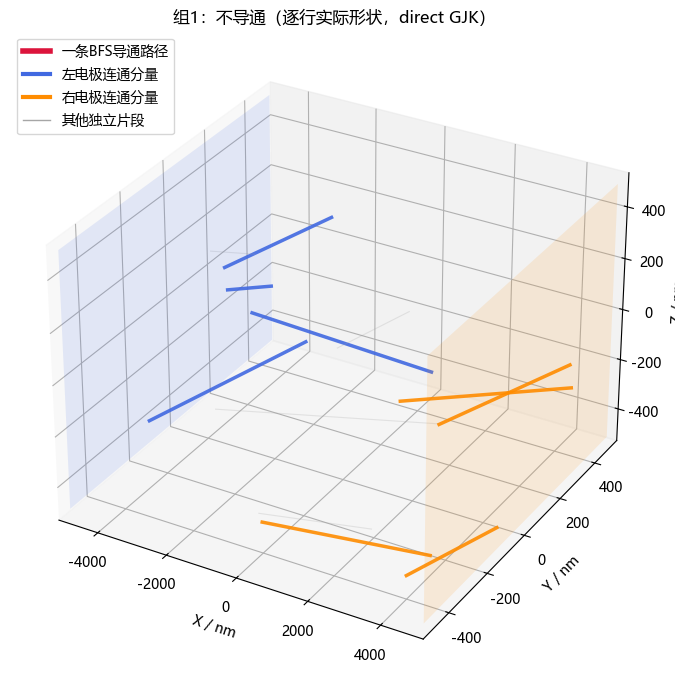

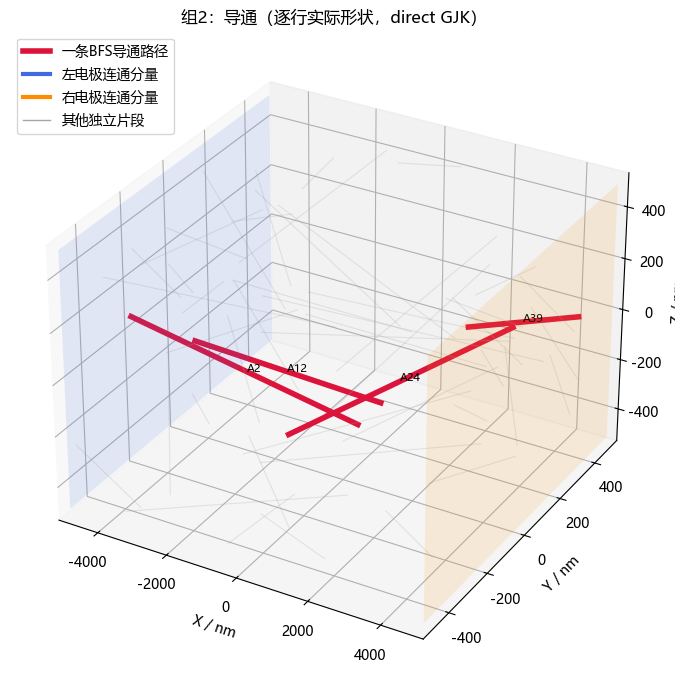

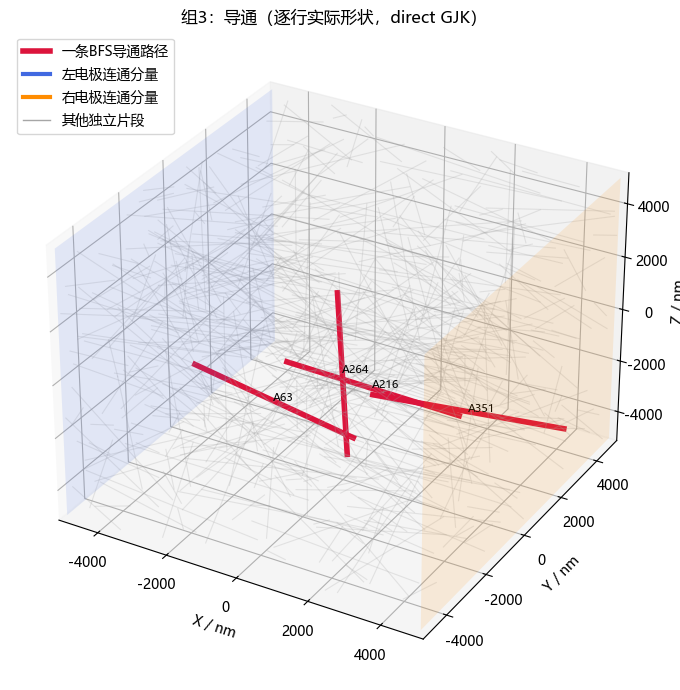

In [10]:
def reachable_nodes(adjacency: np.ndarray, starts: np.ndarray) -> set[int]:
    reached = set(map(int, np.flatnonzero(starts)))
    queue = deque(reached)
    while queue:
        node = queue.popleft()
        for neighbor in map(int, np.flatnonzero(adjacency[node])):
            if neighbor not in reached:
                reached.add(neighbor)
                queue.append(neighbor)
    return reached


def plot_sheet(sheet_name: str, result: dict):
    fig = plt.figure(figsize=(12, 7))
    ax = fig.add_subplot(111, projection="3d")
    path_indices = {piece_id - 1 for piece_id in (result["path"] or [])}
    left_component = reachable_nodes(result["adjacency"], result["left"])
    right_component = reachable_nodes(result["adjacency"], result["right"])

    for index, segment in enumerate(result["segments"]):
        if index in path_indices:
            color, width, alpha = "crimson", 4.0, 1.0
        elif result["path"] is None and index in left_component:
            color, width, alpha = "royalblue", 2.5, 0.9
        elif result["path"] is None and index in right_component:
            color, width, alpha = "darkorange", 2.5, 0.9
        else:
            color, width, alpha = "0.65", 0.8, 0.25

        p, q = segment.p0, segment.p1
        ax.plot(
            [p[0], q[0]], [p[1], q[1]], [p[2], q[2]],
            color=color, lw=width, alpha=alpha,
        )
        if index in path_indices:
            midpoint = 0.5 * (p + q)
            ax.text(*midpoint, f"A{index+1}", fontsize=8)

    half = result["half_extents"]
    Y, Z = np.meshgrid(
        np.array([-half[1], half[1]]),
        np.array([-half[2], half[2]]),
    )
    for x, color in [(-half[0], "royalblue"), (half[0], "darkorange")]:
        ax.plot_surface(
            np.full_like(Y, x, dtype=float), Y, Z,
            color=color, alpha=0.12, shade=False,
        )

    padding = np.maximum(30.0, 0.03 * half)
    ax.set_xlim(-half[0] - padding[0], half[0] + padding[0])
    ax.set_ylim(-half[1] - padding[1], half[1] + padding[1])
    ax.set_zlim(-half[2] - padding[2], half[2] + padding[2])
    ax.set_xlabel("X / nm")
    ax.set_ylabel("Y / nm")
    ax.set_zlabel("Z / nm")
    ax.set_title(
        f"{sheet_name}：{'导通' if result['conductive'] else '不导通'}"
        "（逐行实际形状，direct GJK）"
    )
    ax.legend(handles=[
        Line2D([0], [0], color="crimson", lw=4, label="一条BFS导通路径"),
        Line2D([0], [0], color="royalblue", lw=3, label="左电极连通分量"),
        Line2D([0], [0], color="darkorange", lw=3, label="右电极连通分量"),
        Line2D([0], [0], color="0.65", lw=1, label="其他独立片段"),
    ], loc="upper left")
    plt.tight_layout()
    if IN_NOTEBOOK:
        plt.show()
    else:
        plt.close(fig)


for sheet_name, result in results.items():
    plot_sheet(sheet_name, result)

## 10. 第一问结论与模型边界

本次计算严格采用“一行一个独立实际片段”的口径：

- 不拼接同源行；
- 不恢复或补足到5000 nm；
- 不生成周期副本；
- 内部端点为真实圆盖，边界端点为真实边界切面；
- 只按主单元内直接欧氏距离连接；
- 左右两个X面作为不同电极。

节点数分别为12、49、535，补生成片段数均为0。最终判定为

\[
\boxed{\text{组1不导通，组2导通，组3导通}}.
\]

组2的一条路径为附件数据行 2→12→24→39，组3为 63→264→216→351；
组1不存在同时接触左右电极的普通连通分量。

最接近1.8 nm阈值的连接距离为1.7786710871 nm，不连接距离为1.8439571373 nm，
均与阈值保持明显间隔。